<H1 style="background-color: gold">1-Import Library</H1> 

In [2]:
import os
import re
import time
import certifi
import requests
import torch
import pandas as pd
from tqdm import tqdm
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
import xml.etree.ElementTree as ET
import csv
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor, as_completed
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.cm as cm
import numpy as np
import seaborn as sns
import unicodedata
from rapidfuzz import fuzz, process
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import multiprocessing as mp
from sentence_transformers import SentenceTransformer, util
import concurrent.futures
import random
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
)
import joblib
import warnings
import spacy
from collections import Counter
from collections import deque
import threading
from urllib.parse import urlparse, urlunparse
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import label_binarize

<H1 style="background-color: gold">2-Semantic Alignment between ICD-11 and ERC with Synonyms</H1> 

<h3>1-1-Create Concept Text</h3>

In [2]:
path_icd = "SEARCH_RESULTS_MMS_CLEANED.csv"
path_erc = "ERC_cleaned.csv"
path_gold = "ERC_Gold_Standard.csv"

icd = pd.read_csv(path_icd)
erc = pd.read_csv(path_erc)
gold = pd.read_csv(path_gold)

print("Files loaded:")
print("ICD (Search + MMS):", icd.shape)
print("ERC:", erc.shape)
print("Gold:", gold.shape)

# =========================
# LIGHT NORMALIZATION ONLY
# (keep essential, remove redundancy)
# =========================
def light_clean(text):
    if pd.isna(text):
        return ""
    return str(text).strip().lower()

# Apply only where it matters
icd["Search_Title"] = icd["Search_Title"].apply(light_clean)
icd["Search_Definition"] = icd["Search_Definition"].apply(light_clean)

# =========================
# CREATE CONCEPT TEXT FIELD
# =========================

# ICD concept = Search title + definition + synonyms
icd["concept_text"] = (
    icd["Search_Title"].fillna('') + " " +
    icd["Search_Definition"].fillna('') + " " +
    icd["Search_Synonyms"].fillna('')
).str.replace(r'\s+', ' ', regex=True)

# ERC concept = title + subdivision + definition
erc["concept_text"] = (
    erc["Title_clean"].fillna('') + " " +
    erc["Subdivision_clean"].fillna('') + " " +
    erc["Definition_clean"].fillna('')
).str.replace(r'\s+', ' ', regex=True)

print("\nConcept text created")

# =========================
# SAVE OUTPUT (PHASE 0)
# =========================
icd_filtered_path = "ICD11_Search_MMS_phase0_WithSynonyms.csv"
erc_filtered_path = "ERC_phase0_WithSynonyms.csv"

icd.to_csv(icd_filtered_path, index=False)
erc.to_csv(erc_filtered_path, index=False)

print("Saved ICD:", icd_filtered_path)
print("Saved ERC:", erc_filtered_path)

# =========================
# SANITY CHECK
# =========================
print("\nICD concept_text types:")
print(icd["concept_text"].apply(type).value_counts())

print("\nERC concept_text types:")
print(erc["concept_text"].apply(type).value_counts())

Files loaded:
ICD (Search + MMS): (4746, 12)
ERC: (308, 9)
Gold: (332, 12)

Concept text created
Saved ICD: ICD11_Search_MMS_phase0_WithSynonyms.csv
Saved ERC: ERC_phase0_WithSynonyms.csv

ICD concept_text types:
concept_text
<class 'str'>    4746
Name: count, dtype: int64

ERC concept_text types:
concept_text
<class 'str'>    308
Name: count, dtype: int64


<h3>1-2-Semantic Alignment using SentenceTransformer Models </h3>

In [3]:
TOP_K = 1
MODEL_NAME = "all-mpnet-base-v2"

# =========================
# LOAD FILES
# =========================
icd = pd.read_csv("ICD11_Search_MMS_phase0_WithSynonyms.csv")
erc = pd.read_csv("ERC_phase0_WithSynonyms.csv")

print("ICD:", icd.shape)
print("ERC:", erc.shape)

# =========================
# LOAD MODEL
# =========================
model = SentenceTransformer(MODEL_NAME)

# =========================
# COMPUTE EMBEDDINGS
# =========================
icd_embeddings = model.encode(
    icd["concept_text"].tolist(),
    convert_to_tensor=True,
    normalize_embeddings=True
)

erc_embeddings = model.encode(
    erc["concept_text"].tolist(),
    convert_to_tensor=True,
    normalize_embeddings=True
)

# =========================
# TOP-K MATCHING
# =========================
results = []

for i, erc_row in tqdm(erc.iterrows(), total=len(erc)):

    erc_vec = erc_embeddings[i]
    cos_scores = util.cos_sim(erc_vec, icd_embeddings)[0]

    top_k_scores, top_k_indices = torch.topk(cos_scores, k=TOP_K)

    for rank, (score, idx) in enumerate(zip(top_k_scores, top_k_indices), start=1):

        score = float(score)
        icd_row = icd.iloc[int(idx)]

        # relationship labeling (can be refined later)
        if score >= 0.72:
            relation = "Equivalent"
        elif score >= 0.60:
            relation = "ERC-Narrower"
        elif score >= 0.50:
            relation = "ERC-Broader"
        elif score >= 0.30:
            relation = "Related to"
        else:
            relation = "No match"

        results.append({
            # ERC
            "ERC_ID": erc_row["ERC_ID"],
            "ERC_Title": erc_row["Title_clean"],
            "ERC_Definition": erc_row["Definition_clean"],

            # ICD
            "ICD_MMS_Code": icd_row["MMS_Code"],
            "ICD_MMS_Title": icd_row["MMS_Title"],
            "ICD_Search_Title": icd_row["Search_Title"],
            "ICD_Search_Definition": icd_row["Search_Definition"],
            "Search_Synonyms" : icd_row["Search_Synonyms"],

            # Matching info
            "Rank": rank,
            "Similarity_Score": score,
            "Relationship": relation
        })

# =========================
# SAVE RESULTS
# =========================
df_matches = pd.DataFrame(results)
df_matches.to_csv("ERC_ICD_matches_phase1_topWithSynonyms.csv", index=False)
df_matches.head(10)


ICD: (4746, 13)
ERC: (308, 10)


100%|██████████| 308/308 [00:01<00:00, 156.07it/s]


,ERC_ID,ERC_Title,ERC_Definition,ICD_MMS_Code,ICD_MMS_Title,ICD_Search_Title,ICD_Search_Definition,Search_Synonyms,Rank,Similarity_Score,Relationship
0,A1,Transport accident,Adverse event in transport resulting in proper...,PA0B,Unintentional land transport traffic event inj...,unintentional land transport traffic event inj...,NaN,occupant of special vehicle mainly used on ind...,1,0.814492,Equivalent
1,A11,Transport accident,Transport accident involving a collision of ve...,PA04,Unintentional land transport traffic event inj...,unintentional land transport traffic event inj...,NaN,car occupant injured in transport accident,1,0.798935,Equivalent
2,A12,Transport accident,Transport accident involving a crash of vehicl...,PA41.0,Unintentional water transport injury event wit...,unintentional water transport injury event wit...,NaN,Accident to watercraft causing drowning and su...,1,0.682187,ERC-Narrower
3,A13,Transport accident,Transport accident involving an entrapment of ...,ICD-11 block title,Railway transport injury event of undetermined...,railway transport injury event of undetermined...,NaN,NaN,1,0.681379,ERC-Narrower
4,A2,Fall,An adverse event involving a loss of stability...,PA60,Unintentional fall on the same level or from l...,unintentional fall on the same level or from l...,NaN,ground level fall; fell while ambulating; fall...,1,0.751569,Equivalent
5,A21,Fall,"Falling downward due to gravity, but without a...",PA60,Unintentional fall on the same level or from l...,unintentional fall on the same level or from l...,NaN,ground level fall; fell while ambulating; fall...,1,0.773726,Equivalent
6,A22,Fall,"Falling downward due to gravity, with a signif...",PA60,Unintentional fall on the same level or from l...,unintentional fall on the same level or from l...,NaN,ground level fall; fell while ambulating; fall...,1,0.718676,ERC-Narrower
7,A23,Fall,"Falling downward due to gravity, where the hei...",ICD-11 block title,Fall or jump with undetermined intent,fall or jump with undetermined intent,NaN,fall from height NOS,1,0.674485,ERC-Narrower
8,A3,Natural disaster,Adverse event with one or more direct natural ...,PA24,Unintentional land transport event unknown whe...,unintentional land transport event unknown whe...,NaN,unintentional off-road crash injuring a motor ...,1,0.556639,ERC-Broader
9,A31,Natural disaster,Natural disaster caused by strong wind,PJ06,Victim of cataclysmic storm,victim of cataclysmic storm,NaN,NaN,1,0.576103,ERC-Broader


<H3>1-3-Initial evaluation of samples based on matching terminology identifiers</H3>

Prediction: (308, 11)
Gold: (332, 12)
Evaluation pairs: 9

====== EVALUATION (CODE + RELATION) ======
Pairs evaluated : 9
Accuracy        : 0.667
Precision       : 0.406
Recall          : 0.375
F1-score        : 0.359


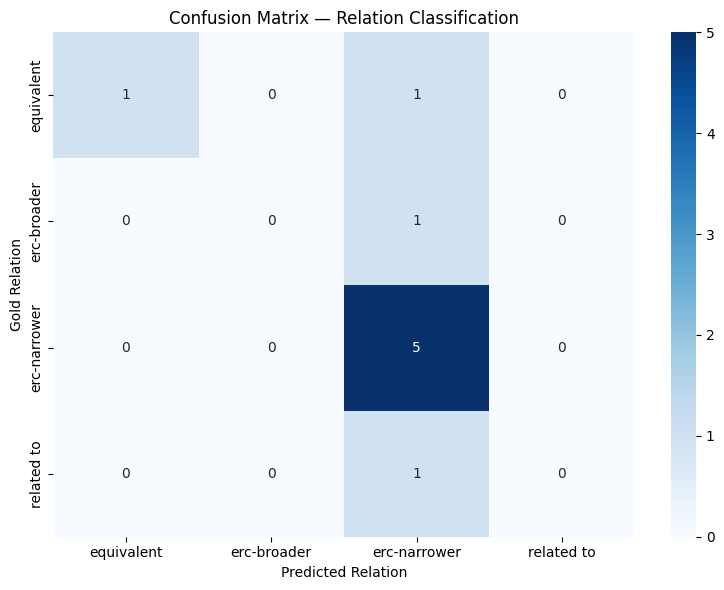

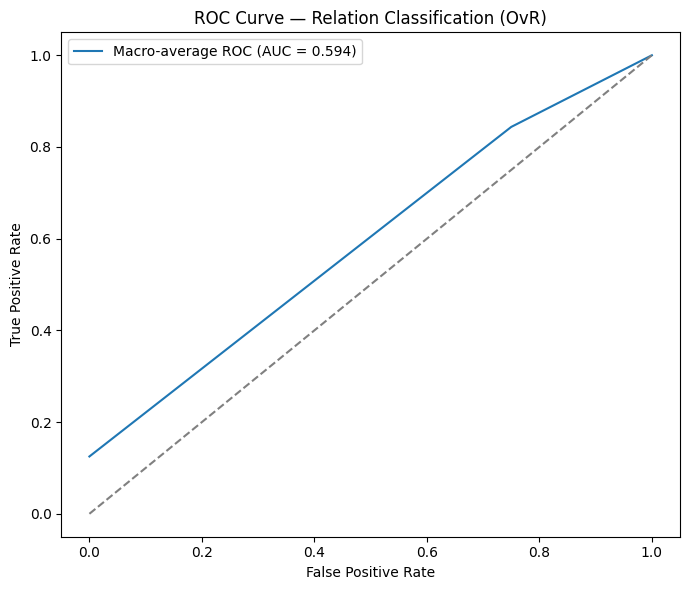

ROC AUC (macro-average): 0.594


In [3]:
pred = pd.read_csv("ERC_ICD_matches_phase1_topWithSynonyms.csv", dtype=str).fillna("")
gold = pd.read_csv("ERC_Gold_Standard.csv", dtype=str).fillna("")

print("Prediction:", pred.shape)
print("Gold:", gold.shape)

# =========================
# NORMALIZE IDS & CODES
# =========================
def norm(x):
    return str(x).strip().lower().replace(" ", "").replace("-", "")

pred["ERC_ID_norm"] = pred["ERC_ID"].apply(norm)
pred["ICD_Code_norm"] = pred["ICD_MMS_Code"].apply(norm)

gold["ERC_ID_norm"] = gold["No. / Nr."].apply(norm)
gold["ICD_Code_norm"] = gold["ICD-11 Code"].apply(norm)

# =========================
# KEEP ONLY COMMON ERC–ICD PAIRS
# =========================
pred["PAIR_KEY"] = pred["ERC_ID_norm"] + "||" + pred["ICD_Code_norm"]
gold["PAIR_KEY"] = gold["ERC_ID_norm"] + "||" + gold["ICD_Code_norm"]

common_pairs = set(pred["PAIR_KEY"]) & set(gold["PAIR_KEY"])

pred_eval = pred[pred["PAIR_KEY"].isin(common_pairs)].copy()
gold_eval = gold[gold["PAIR_KEY"].isin(common_pairs)].copy()

print("Evaluation pairs:", pred_eval.shape[0])

# =========================
# MERGE FOR EVALUATION
# =========================
df = pred_eval.merge(
    gold_eval[["PAIR_KEY", "Levels of equivalence"]],
    on="PAIR_KEY",
    how="inner"
)

# =========================
# RELATION COMPARISON ONLY
# =========================
df["Pred_Rel"] = df["Relationship"].str.strip().str.lower()
df["Gold_Rel"] = df["Levels of equivalence"].str.strip().str.lower()

df["Correct"] = df["Pred_Rel"] == df["Gold_Rel"]

# =========================
# METRICS
# =========================
accuracy = df["Correct"].mean()

precision = precision_score(
    df["Gold_Rel"], df["Pred_Rel"],
    average="macro", zero_division=0
)

recall = recall_score(
    df["Gold_Rel"], df["Pred_Rel"],
    average="macro", zero_division=0
)

f1 = f1_score(
    df["Gold_Rel"], df["Pred_Rel"],
    average="macro", zero_division=0
)

print("\n====== EVALUATION (CODE + RELATION) ======")
print(f"Pairs evaluated : {df.shape[0]}")
print(f"Accuracy        : {accuracy:.3f}")
print(f"Precision       : {precision:.3f}")
print(f"Recall          : {recall:.3f}")
print(f"F1-score        : {f1:.3f}")
print("====================================================")

# ======================================================
# CONFUSION MATRIX (RELATIONS)
# ======================================================
labels = sorted(set(df["Gold_Rel"]) | set(df["Pred_Rel"]))

cm = confusion_matrix(
    df["Gold_Rel"], df["Pred_Rel"],
    labels=labels
)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm, annot=True, fmt="d",
    xticklabels=labels,
    yticklabels=labels,
    cmap="Blues"
)
plt.title("Confusion Matrix — Relation Classification")
plt.xlabel("Predicted Relation")
plt.ylabel("Gold Relation")
plt.tight_layout()
plt.show()

# ======================================================
# ROC CURVE + AUC (MULTICLASS — ONE VS REST)
# ======================================================
le = LabelEncoder()
y_true = le.fit_transform(df["Gold_Rel"])
y_pred = le.transform(df["Pred_Rel"])

# Binarize labels
classes = np.unique(y_true)
y_true_bin = label_binarize(y_true, classes=classes)
y_pred_bin = label_binarize(y_pred, classes=classes)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i, cls in enumerate(classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Macro-average ROC
all_fpr = np.unique(np.concatenate([fpr[i] for i in classes]))
mean_tpr = np.zeros_like(all_fpr)

for i in classes:
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= len(classes)
macro_auc = auc(all_fpr, mean_tpr)

# Plot ROC
plt.figure(figsize=(7,6))
plt.plot(all_fpr, mean_tpr, label=f"Macro-average ROC (AUC = {macro_auc:.3f})")
plt.plot([0,1],[0,1],"--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Relation Classification (OvR)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"ROC AUC (macro-average): {macro_auc:.3f}")

<h3>1-4-Final Gold Evaluation – Relation</h3>

In [4]:

PRED_FILE = "ERC_ICD_matches_phase1_topWithSynonyms.csv"
GOLD_FILE = "ERC_Gold_Standard.csv"

pred = pd.read_csv(PRED_FILE, dtype=str).fillna("")
gold = pd.read_csv(GOLD_FILE, dtype=str).fillna("")
def norm(x):
    return (
        str(x)
        .strip()
        .lower()
        .replace(" ", "")
        .replace("-", "")
        .replace(".", "")
    )

pred["ERC_norm"] = pred["ERC_ID"].apply(norm)
pred["ICD_norm"] = pred["ICD_MMS_Code"].apply(norm)
pred["REL_norm"] = pred["Relationship"].astype(str).str.strip().str.lower()

gold["ERC_norm"] = gold["No. / Nr."].apply(norm)
gold["ICD_norm"] = gold["ICD-11 Code"].apply(norm)
gold["REL_norm"] = gold["Levels of equivalence"].astype(str).str.strip().str.lower()

pred["PAIR_KEY"] = pred["ERC_norm"] + "||" + pred["ICD_norm"]
gold["PAIR_KEY"] = gold["ERC_norm"] + "||" + gold["ICD_norm"]
# KEEP ONLY COMMON PAIRS
common_pairs = set(pred["PAIR_KEY"]) & set(gold["PAIR_KEY"])

pred_eval = pred[pred["PAIR_KEY"].isin(common_pairs)]
gold_eval = gold[gold["PAIR_KEY"].isin(common_pairs)]

print("Pairs evaluated:", len(pred_eval))
# MERGE
df = pred_eval.merge(
    gold_eval[["PAIR_KEY", "REL_norm"]],
    on="PAIR_KEY",
    how="inner",
    suffixes=("_pred", "_gold")
)
# CORRECTNESS FLAGS
df["code_correct"] = 1 
df["relation_correct"] = (df["REL_norm_pred"] == df["REL_norm_gold"]).astype(int)

df["final_correct"] = ((df["code_correct"] == 1) & (df["relation_correct"] == 1)).astype(int)
# METRICS (STRICT)
y_true = [1] * len(df)         
y_pred = df["final_correct"]

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

print("\n===== Final ERC–ICD–RELATION EVALUATION =====")
print(f"Evaluated pairs : {len(df)}")
print(f"Accuracy        : {accuracy:.4f}")
print(f"Precision       : {precision:.4f}")
print(f"Recall          : {recall:.4f}")
print(f"F1-score        : {f1:.4f}")
print("============================================")

print("\nRelation classification report:")
print(classification_report(
    df["REL_norm_gold"],
    df["REL_norm_pred"],
    zero_division=0
))

Pairs evaluated: 61

===== Final ERC–ICD–RELATION EVALUATION =====
Evaluated pairs : 61
Accuracy        : 0.5082
Precision       : 1.0000
Recall          : 0.5082
F1-score        : 0.6739

Relation classification report:
              precision    recall  f1-score   support

  equivalent       0.80      0.48      0.60        33
 erc-broader       0.00      0.00      0.00         5
erc-narrower       0.47      0.75      0.58        20
  related to       0.00      0.00      0.00         3

    accuracy                           0.51        61
   macro avg       0.32      0.31      0.30        61
weighted avg       0.59      0.51      0.52        61



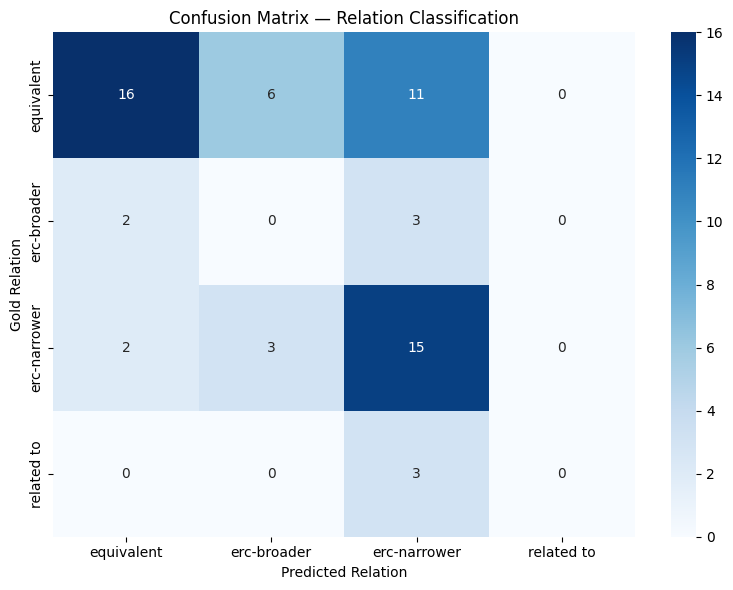

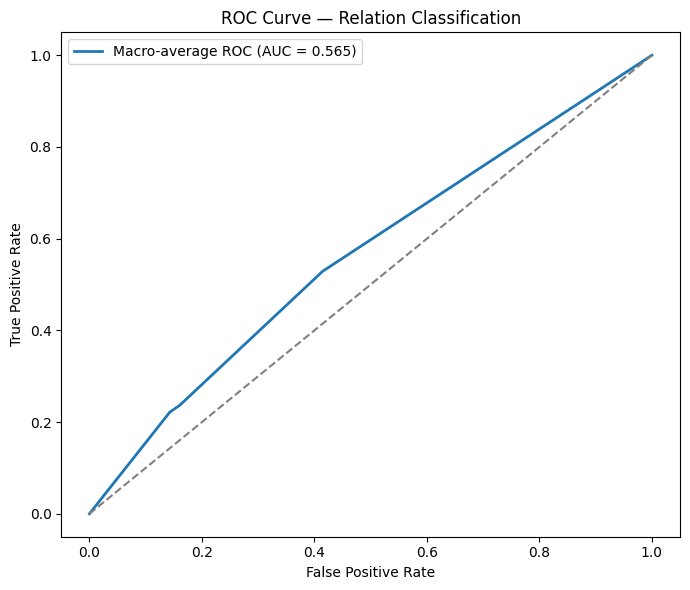


ROC AUC (macro-average): 0.565


In [5]:
# =========================
# CONFUSION MATRIX (RELATIONS)
# =========================
labels = sorted(set(df["REL_norm_gold"]) | set(df["REL_norm_pred"]))

cm = confusion_matrix(
    df["REL_norm_gold"],
    df["REL_norm_pred"],
    labels=labels
)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)
plt.title("Confusion Matrix — Relation Classification")
plt.xlabel("Predicted Relation")
plt.ylabel("Gold Relation")
plt.tight_layout()
plt.show()

# =========================
# ROC CURVE + AUC (MULTICLASS OvR)
# =========================
le = LabelEncoder()
y_true = le.fit_transform(df["REL_norm_gold"])
y_pred = le.transform(df["REL_norm_pred"])

classes = np.unique(y_true)

# Binarize
y_true_bin = label_binarize(y_true, classes=classes)
y_pred_bin = label_binarize(y_pred, classes=classes)

fpr = {}
tpr = {}
roc_auc = {}

for i, cls in enumerate(classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Macro-average ROC
all_fpr = np.unique(np.concatenate([fpr[i] for i in classes]))
mean_tpr = np.zeros_like(all_fpr)

for i in classes:
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= len(classes)
macro_auc = auc(all_fpr, mean_tpr)

# Plot ROC
plt.figure(figsize=(7,6))
plt.plot(
    all_fpr,
    mean_tpr,
    label=f"Macro-average ROC (AUC = {macro_auc:.3f})",
    linewidth=2
)
plt.plot([0,1],[0,1],"--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Relation Classification")
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nROC AUC (macro-average): {macro_auc:.3f}")
